# Classical Machine Learning for Amazon Fake Review Detection

This notebook builds a classical machine learning pipeline for fake review detection using the processed labeled Amazon review dataset.

We will compare three supervised baselines, evaluate them consistently, and save the best artifacts for later reuse.

## Imports

In [12]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

## Load Dataset

Loaded dataset from: ../data/processed/labeled_reviews.csv
Shape: (84621, 14)


,content,content_clean,score,is_exact_dup,is_near_dup,is_burst_day,is_one_hit_wonder,rating_deviation,exclamation_count,word_count,avg_word_len,superlative_count,fake_score,pseudo_label
0,I just like how quickly Amazon delivers,i just like how quickly amazon delivers,5,0.0,0.0,0.0,1.0,0.642031,0,7,4.714286,0,0.214203,0
1,Good,good,5,1.0,1.0,0.0,1.0,NaN,0,1,4.000000,0,NaN,0
2,worst company terrible delivery service. they ...,worst company terrible delivery service. they ...,1,0.0,0.0,0.0,1.0,0.514038,0,21,5.333333,2,0.201404,0
3,"quick delivery, great prices and i was refunde...","quick delivery, great prices and i was refunde...",5,0.0,0.0,0.0,1.0,0.622247,0,15,4.400000,0,0.212225,0
4,it was good using this application,it was good using this application,5,0.0,0.0,0.0,1.0,0.632474,0,6,4.833333,0,0.213247,0


Data types:


,dtype
content,str
content_clean,str
score,int64
is_exact_dup,float64
is_near_dup,float64
is_burst_day,float64
is_one_hit_wonder,float64
rating_deviation,float64
exclamation_count,int64
word_count,int64


Missing values per column:


fake_score          9644
rating_deviation    9644
content_clean        617
dtype: int64

Pseudo label distribution:


pseudo_label
0    73380
1    11241
Name: count, dtype: int64

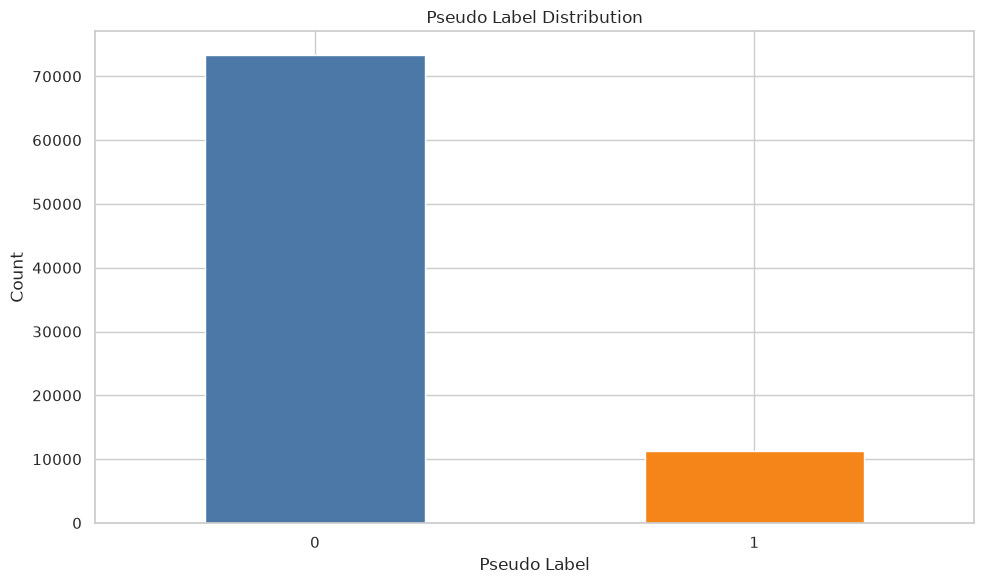

In [13]:
data_path = Path('../data/processed/labeled_reviews.csv')
if not data_path.exists():
    raise FileNotFoundError(f'Could not find the dataset at {data_path} or {fallback_path}')

df = pd.read_csv(data_path)

if 'pseudo_label' not in df.columns:
    raise KeyError("Expected target column 'pseudo_label' was not found in the dataset.")

print(f'Loaded dataset from: {data_path}')
print(f'Shape: {df.shape}')
display(df.head())

print('Data types:')
display(df.dtypes.to_frame(name='dtype'))

print('Missing values per column:')
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_series = missing_counts[missing_counts > 0]
display(missing_series if not missing_series.empty else pd.Series(dtype='int64'))

print('Pseudo label distribution:')
pseudo_label_counts = df['pseudo_label'].value_counts().sort_index()
display(pseudo_label_counts)

ax = pseudo_label_counts.plot(kind='bar', color=['#4c78a8', '#f58518'])
ax.set_title('Pseudo Label Distribution')
ax.set_xlabel('Pseudo Label')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Data Preparation

In [24]:
target_column = 'pseudo_label'
text_column = 'content_clean'

y = df[target_column].astype(int)

# Select feature columns (excluding target and pseudo-label calculation leakage)
keep_cols = [
    'score',
    'word_count',
    'avg_word_len',
    'exclamation_count',
    'superlative_count'
]

# Extract text and numeric feature frames prior to train/test split to prevent data leakage
df_features = df[[text_column] + keep_cols].copy()
for col in keep_cols:
    df_features[col] = df_features[col].fillna(df_features[col].median())
df_features[text_column] = df_features[text_column].fillna('').astype(str)


## Train/Test Split

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84621 entries, 0 to 84620
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content            84621 non-null  str    
 1   content_clean      84004 non-null  str    
 2   score              84621 non-null  int64  
 3   is_exact_dup       84621 non-null  float64
 4   is_near_dup        84621 non-null  float64
 5   is_burst_day       84621 non-null  float64
 6   is_one_hit_wonder  84621 non-null  float64
 7   rating_deviation   74977 non-null  float64
 8   exclamation_count  84621 non-null  int64  
 9   word_count         84621 non-null  int64  
 10  avg_word_len       84621 non-null  float64
 11  superlative_count  84621 non-null  int64  
 12  fake_score         74977 non-null  float64
 13  pseudo_label       84621 non-null  int64  
dtypes: float64(7), int64(5), str(2)
memory usage: 9.0 MB


In [25]:
# Perform stratified Train/Test split FIRST before fitting TF-IDF to avoid data leakage
X_train_df, X_test_df, y_train, y_test = train_test_split(df_features, y, test_size=0.2, random_state=42, stratify=y)

# Fit TfidfVectorizer STRICTLY on X_train only
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_text = tfidf.fit_transform(X_train_df[text_column])
X_test_text = tfidf.transform(X_test_df[text_column])

# Stack text and numeric features
X_train_num = csr_matrix(X_train_df[keep_cols].values)
X_test_num = csr_matrix(X_test_df[keep_cols].values)

X_train = hstack([X_train_text, X_train_num])
X_test = hstack([X_test_text, X_test_num])

print(f'Training set shape: {X_train.shape}')
print(f'Testing set shape: {X_test.shape}')

print('Training label distribution:')
display(y_train.value_counts(normalize=True).sort_index())
print('Testing label distribution:')
display(y_test.value_counts(normalize=True).sort_index())


Training set shape: (67696, 5005)
Testing set shape: (16925, 5005)
Training label distribution:


pseudo_label
0    0.867156
1    0.132844
Name: proportion, dtype: float64

Testing label distribution:


pseudo_label
0    0.867179
1    0.132821
Name: proportion, dtype: float64

## Train Three Models

In [26]:
positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1.0

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        solver='liblinear',
        class_weight='balanced',
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced',
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
    ),
}

trained_models = {}
for model_name, model in models.items():
    print(f'\nTraining {model_name}...')
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    print(f'Finished training {model_name}.')


Training Logistic Regression...
Finished training Logistic Regression.

Training Random Forest...
Finished training Random Forest.

Training XGBoost...
Finished training XGBoost.


## Evaluation


Logistic Regression Evaluation
Accuracy: 0.7030
Precision: 0.2557
Recall: 0.6468
F1: 0.3665
ROC-AUC: 0.7337

Classification Report:
              precision    recall  f1-score   support

     genuine     0.9293    0.7116    0.8060     14677
        fake     0.2557    0.6468    0.3665      2248

    accuracy                         0.7030     16925
   macro avg     0.5925    0.6792    0.5862     16925
weighted avg     0.8399    0.7030    0.7476     16925



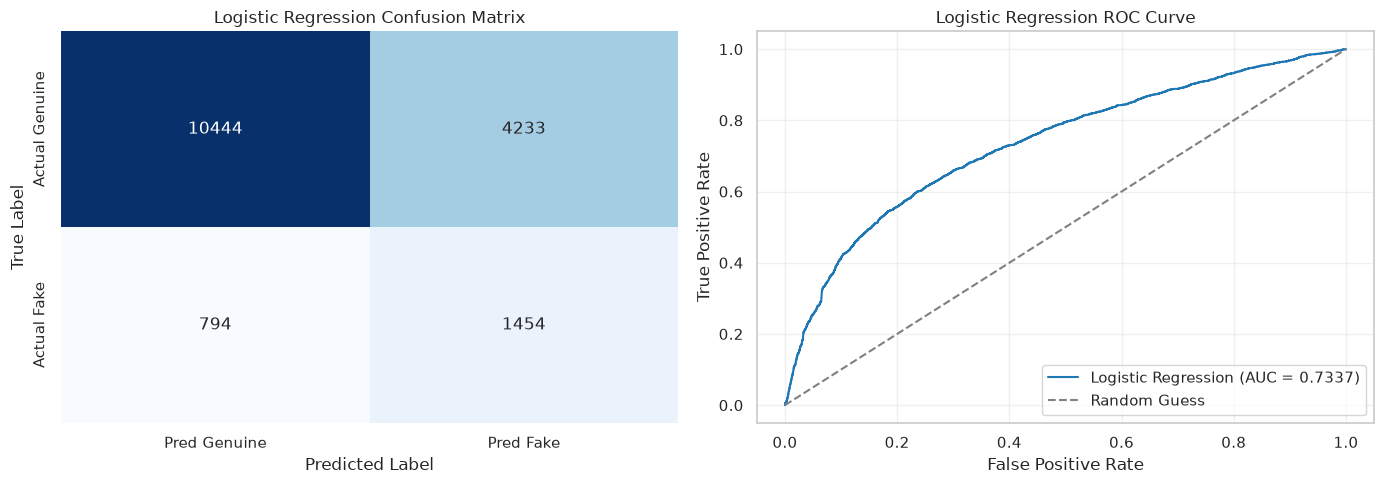


Random Forest Evaluation
Accuracy: 0.8799
Precision: 0.5716
Recall: 0.3835
F1: 0.4590
ROC-AUC: 0.7613

Classification Report:
              precision    recall  f1-score   support

     genuine     0.9101    0.9560    0.9325     14677
        fake     0.5716    0.3835    0.4590      2248

    accuracy                         0.8799     16925
   macro avg     0.7409    0.6697    0.6957     16925
weighted avg     0.8651    0.8799    0.8696     16925



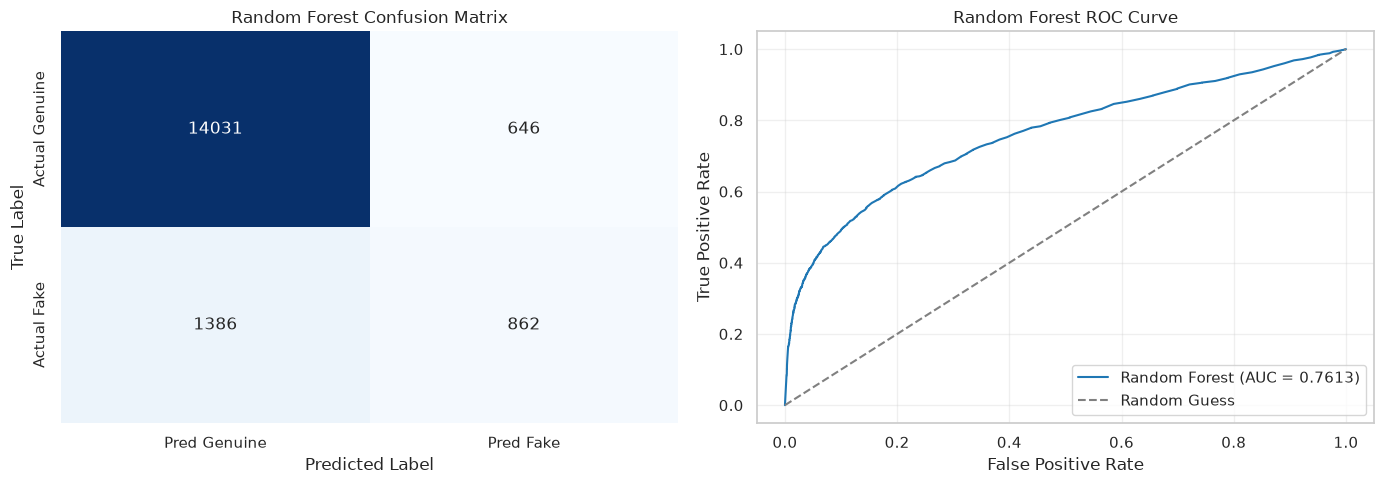


XGBoost Evaluation
Accuracy: 0.7925
Precision: 0.3340
Recall: 0.5658
F1: 0.4201
ROC-AUC: 0.7566

Classification Report:
              precision    recall  f1-score   support

     genuine     0.9256    0.8272    0.8736     14677
        fake     0.3340    0.5658    0.4201      2248

    accuracy                         0.7925     16925
   macro avg     0.6298    0.6965    0.6469     16925
weighted avg     0.8470    0.7925    0.8134     16925



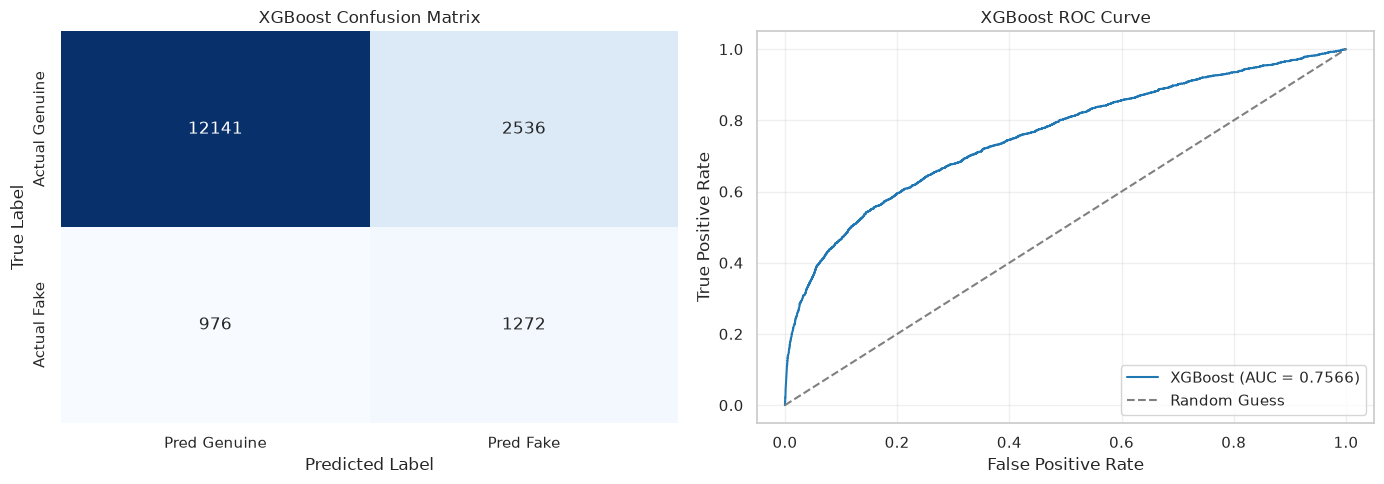

In [27]:
evaluation_results = []

def evaluate_model(model_name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)

    metrics_dict = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred, zero_division=0),
        'Recall': recall_score(y_eval, y_pred, zero_division=0),
        'F1': f1_score(y_eval, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_eval, y_score),
    }

    separator = '=' * 80
    print(f'\n{separator}')
    print(f'{model_name} Evaluation')
    print(f'{separator}')
    for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
        print(f'{metric_name}: {metrics_dict[metric_name]:.4f}')

    print('\nClassification Report:')
    print(classification_report(
        y_eval,
        y_pred,
        target_names=['genuine', 'fake'],
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_eval, y_pred)
    fpr, tpr, _ = roc_curve(y_eval, y_score)
    roc_auc_value = metrics_dict['ROC-AUC']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[0],
        xticklabels=['Pred Genuine', 'Pred Fake'],
        yticklabels=['Actual Genuine', 'Actual Fake'],
    )
    axes[0].set_title(f'{model_name} Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')

    axes[1].plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_value:.4f})', color='#1f77b4')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    axes[1].set_title(f'{model_name} ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return metrics_dict

for model_name, model in trained_models.items():
    evaluation_results.append(evaluate_model(model_name, model, X_test, y_test))

## Model Comparison

In [28]:
comparison_df = pd.DataFrame(evaluation_results).sort_values(by=['ROC-AUC', 'F1'], ascending=False).reset_index(drop=True)
display(comparison_df)

results_dir = Path('../results/metrics')
results_dir.mkdir(parents=True, exist_ok=True)
comparison_path = results_dir / 'model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'Saved model comparison table to: {comparison_path}')

best_model_name = comparison_df.iloc[0]['Model']
best_model_metrics = comparison_df.iloc[0]
print(f'\nBest model according to ROC-AUC and F1: {best_model_name}')
print(best_model_metrics.to_string())

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.879941,0.571618,0.383452,0.458999,0.761295
1,XGBoost,0.792496,0.334034,0.565836,0.420079,0.756593
2,Logistic Regression,0.702984,0.255671,0.646797,0.366478,0.733696


Saved model comparison table to: ../results/metrics/model_comparison.csv

Best model according to ROC-AUC and F1: Random Forest
Model        Random Forest
Accuracy          0.879941
Precision         0.571618
Recall            0.383452
F1                0.458999
ROC-AUC           0.761295


## Save Models

In [29]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

for model_name, model in trained_models.items():
    filename = model_name.lower().replace(' ', '_') + '.pkl'
    model_path = models_dir / filename
    joblib.dump(model, model_path)
    print(f'Saved {model_name} to: {model_path}')
# Also save the TF-IDF vectorizer -- without it, the saved models can't
# turn new, unseen review text into the same feature format they were
# trained on, which makes them useless outside this notebook session.
vectorizer_path = models_dir / 'tfidf_vectorizer.pkl'
joblib.dump(tfidf, vectorizer_path)
print(f'Saved TF-IDF vectorizer to: {vectorizer_path}')


Saved Logistic Regression to: ../models/logistic_regression.pkl
Saved Random Forest to: ../models/random_forest.pkl
Saved XGBoost to: ../models/xgboost.pkl


## Live Demo -- Test the Model on New Reviews

Reloads the saved model + vectorizer from disk (exactly like a real app would) and runs predictions on a few brand-new sentences that were never in the training data.

In [ ]:
# Reload from disk to prove the saved artifacts actually work standalone --
# this is exactly what a real app / API would do: load once, predict many times.
import re
import numpy as np
import joblib
from pathlib import Path
from scipy.sparse import csr_matrix, hstack

models_dir = Path('../models')
loaded_vectorizer = joblib.load(models_dir / 'tfidf_vectorizer.pkl')
loaded_model = joblib.load(models_dir / 'random_forest.pkl')

def clean_text(t):
    """Same cleaning used in 01_EDA.ipynb -- must match or the vectorizer
    will see out-of-distribution text."""
    t = str(t).lower()
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'[^a-z0-9\s.,!?\'"-]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

def build_features(raw_text, score, vectorizer):
    """Recreate, for ONE new review, the exact same feature set the model
    was trained on: TF-IDF text vector + 5 numeric signals."""
    cleaned = clean_text(raw_text)
    words = cleaned.split()
    word_count = len(words)
    avg_word_len = np.mean([len(w) for w in words]) if words else 0
    exclamation_count = raw_text.count('!')
    superlative_count = len(re.findall(r'\b(best|worst|amazing|terrible|perfect|awful)\b', cleaned))

    X_text_new = vectorizer.transform([cleaned])
    X_numeric_new = csr_matrix(np.array([[score, word_count, avg_word_len,
                                           exclamation_count, superlative_count]]))
    return hstack([X_text_new, X_numeric_new])

def predict_review(raw_text, score=3, model=loaded_model, vectorizer=loaded_vectorizer):
    """
    score: the star rating (1-5) the reviewer left. Defaults to 3 (neutral)
    if testing free text with no rating -- note `score` IS one of the
    trained numeric features, so predictions are most accurate when you
    pass the review's real star rating.
    """
    X_new = build_features(raw_text, score, vectorizer)
    pred = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0][1]
    label = 'FAKE' if pred == 1 else 'GENUINE'
    print(f"Review: {raw_text!r}  (score={score})")
    print(f"Prediction: {label}  (fake probability: {proba:.2%})\n")
    return label, proba

# --- Live demo for the presentation ---
demo_cases = [
    ("Best app ever!!! Amazing amazing amazing, perfect in every way, buy it now!!!", 5),
    ("The checkout was a bit slow but customer service resolved my issue quickly.", 4),
    ("Terrible, worst purchase, never buying again, awful awful awful experience!!!", 1),
    ("Decent value for the price, delivery took an extra day.", 3),
]

for text, score in demo_cases:
    predict_review(text, score=score)
